# ***Proyecto: Análisis de Calidad de Vinos mediante Reducción de Dimensionalidad y Clasificadores Probabilísticos***

---

* ***Autor:*** Jolehisy Acevedo Medina
* ***Fecha:*** 22/04/2026
* Informática Industrial Avanzada
* Máster en Ingeniería Industrial
* Universidad de La Laguna

---

## ***1. Descripción del Dataset***

Para esta práctica utilizaremos el conjunto de datos **"Wine Quality"**, el cual recopila información fisicoquímica de las variantes de vino tinto y blanco del ***"Vinho Verde"*** portugués. El propósito fundamental es realizar un análisis predictivo para determinar la calidad percibida del vino basándose en sus propiedades químicas.

Las variables de entrada (características) incluidas en el estudio son:

* ***Fixed acidity / Volatile acidity / Citric acid***: Ácidos orgánicos que influyen en el sabor y estabilidad del vino.
* ***Residual sugar***: Azúcar remanente tras la fermentación; factor clave para el dulzor.
* ***Chlorides***: Concentración de sales presentes.
* ***Free sulfur dioxide / Total sulfur dioxide***: Niveles de dióxido de azufre para prevenir la oxidación.
* ***Density / pH / Sulphates***: Parámetros físicos de densidad, nivel de acidez y aditivos antioxidantes.
* ***Alcohol***: Graduación alcohólica, uno de los factores más influyentes en la calidad.

La variable objetivo (***Target***) es:
* ***Quality***: Puntuación sensorial (numérica) que refleja la calidad del vino.

---

## ***2. Objetivos del Proyecto***

El objetivo de este cuaderno es desarrollar un flujo de trabajo de ***Machine Learning*** siguiendo los contenidos y cuadernos base de la asignatura:

1.  ***Análisis Exploratorio de Datos (EDA)***: Realizar un estudio detallado de las estadísticas descriptivas y una **Matriz de Correlación** para identificar qué variables químicas impactan más en la calidad.
2.  ***Preprocesamiento y Limpieza***: Identificar y gestionar valores nulos y aplicar una **Normalización de los datos**, requisito indispensable para el PCA.
3.  ***Reducción de Dimensionalidad (PCA)***: Implementar el **Análisis de Componentes Principales** para simplificar el espacio de características, justificando la varianza explicada.
4.  ***Clasificación Probabilística***: Implementar y entrenar dos modelos de clasificación basados en probabilidad.
5.  ***Evaluación de Modelos y Comparativa***: Contrastar el rendimiento de los modelos **con y sin el uso de PCA**. Se emplearán métricas como: **Matriz de Confusión**, **Precisión (Accuracy)** y **Validación Cruzada (Cross-Validation)**.

## **3. Fase 1: Procesamiento de datos**
### **3.1. Carga del dataset**
Dado que disponemos de los datos tanto para el vino tinto (**Red**) como para el blanco (**White**), procederemos a cargarlos de forma local. Para realizar un análisis global, uniremos ambos conjuntos en un único DataFrame.

**Pasos:**
1. Carga de `winequality-red.csv` y `winequality-white.csv`.
2. Creación de una columna nueva llamada `type` (1 para tinto, 0 para blanco) para que el modelo pueda distinguir el tipo de vino.
3. Concatenación de ambas tablas en una única.

## Librerías

In [75]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_val_predict

In [ ]:
# 1. Cargar los dos archivos locales
df_red = pd.read_csv('winequality-red.csv', sep=';')
df_white = pd.read_csv('winequality-white.csv', sep=';')

# 2. Añadir etiqueta para diferenciar el tipo de vino
df_red['type'] = 1   # Tinto
df_white['type'] = 0  # Blanco

# 3. Unir ambos en un solo DataFrame
df = pd.concat([df_red, df_white], axis=0, ignore_index=True)

# 4. Comprobación
print(f"Total de vinos tintos: {df_red.shape[0]}")
print(f"Total de vinos blancos: {df_white.shape[0]}")
print(f"Dataset total: {df.shape[0]} filas y {df.shape[1]} columnas.")

display(df.sample(20)) # Mostramos 20 filas al azar para ver la mezcla

Total de vinos tintos: 1599
Total de vinos blancos: 4898
Dataset total: 6497 filas y 13 columnas.


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
5346,6.8,0.220,0.30,10.6,0.070,67.0,194.0,0.99654,2.89,0.42,9.00,6,0
1577,6.2,0.700,0.15,5.1,0.076,13.0,27.0,0.99622,3.54,0.60,11.90,6,1
4839,6.4,0.160,0.42,1.0,0.036,29.0,113.0,0.99080,3.18,0.52,11.00,6,0
130,8.0,0.745,0.56,2.0,0.118,30.0,134.0,0.99680,3.24,0.66,9.40,5,1
5522,8.6,0.310,0.30,0.9,0.045,16.0,109.0,0.99249,2.95,0.39,10.10,5,0
3815,7.8,0.300,0.37,1.3,0.051,16.0,96.0,0.99410,3.32,0.62,10.00,5,0
4028,8.1,0.340,0.28,7.5,0.040,70.0,230.0,0.99558,3.14,0.55,9.80,6,0
1944,7.1,0.145,0.33,4.6,0.050,33.0,131.0,0.99420,3.28,0.40,9.60,6,0
5507,6.2,0.390,0.24,4.8,0.037,45.0,138.0,0.99174,3.23,0.43,11.20,7,0
5837,6.4,0.290,0.18,15.0,0.040,21.0,116.0,0.99736,3.14,0.50,9.20,5,0


### 3.2. Estadísticas Descriptivas y Distribuciones
Antes de buscar relaciones entre variables, es fundamental comprender la "forma" individual de cada característica. Este paso nos permite:
1. **Evaluar la escala y dispersión:** Observar si las variables tienen rangos muy distintos.
2. **Detectar asimetrías:** Ver si los datos tienen un comportamiento normal (campana de Gauss) o si están sesgados.
3. **Analizar la Variable Objetivo:** Comprobar si las clases de calidad están balanceadas.

### 3.2.1. Análisis Estadístico Descriptivo

El primer paso para conocer la "forma" de nuestro conjunto de datos es observar sus estadísticas vitales. En este apartado vamos a generar una tabla resumen para evaluar los rangos, las medias y la dispersión de cada característica. Esto nos dará la primera pista matemática sobre si nuestras variables operan en la misma magnitud o si, por el contrario, necesitaremos aplicar técnicas de escalado.

In [60]:
# Mostramos las estadísticas descriptivas de las variables numéricas
# Usamos .T (transpuesta) para que las variables salgan en filas y sea más fácil de leer
estadisticas = df.describe().T
display(estadisticas[['mean', 'std', 'min', '50%', 'max']])

,mean,std,min,50%,max
fixed acidity,7.215179,1.319671,3.80000,7.00000,15.90000
volatile acidity,0.344130,0.168248,0.08000,0.30000,1.58000
citric acid,0.318494,0.147157,0.00000,0.31000,1.66000
residual sugar,5.048477,4.500180,0.60000,2.70000,65.80000
chlorides,0.056690,0.036863,0.00900,0.04700,0.61100
free sulfur dioxide,30.036654,17.805045,1.00000,28.00000,289.00000
total sulfur dioxide,114.109023,56.774223,6.00000,116.00000,440.00000
density,0.994535,0.002966,0.98711,0.99465,1.03898
pH,3.224664,0.160379,2.72000,3.21000,4.01000
sulphates,0.533357,0.149743,0.22000,0.51000,2.00000


***Análisis de resultados (Punto 3.2.1):***

Tras observar las métricas centrales y de dispersión de nuestro conjunto de datos, extraemos tres conclusiones fundamentales que guiarán el preprocesamiento:

* **1. Heterogeneidad de Escalas:** Las variables químicas operan en magnitudes completamente distintas. Por ejemplo, la variable `density` fluctúa en un rango milimétrico (0.987 a 1.038), mientras que el `total sulfur dioxide` presenta una media de 114 y picos de hasta 440. Si introducimos estos datos "crudos" a un algoritmo basado en distancias o varianzas (como PCA o K-Means), el azufre dominará el modelo simplemente por tener números más grandes. **Por tanto, es muy importante aplicar una técnica de escalado**

* **2. Detección de Outliers:**
Al comparar la mediana (percentil 50%) con los valores máximos, detectamos una fuerte asimetría hacia la derecha en ciertas variables. El caso más evidente es el `residual sugar`: el 50% de los vinos tienen 2.7 o menos, pero el valor máximo se dispara hasta 65.8. Esta dispersión sugiere la presencia de valores atípicos (outliers) que representan vinos con características químicas muy inusuales.

* **3. Perfil de la Variable Objetivo (`quality`):**
Nuestra variable a predecir es categórica ordinal (escala del 3 al 9). La media (5.79) y la mediana (6.0) son prácticamente idénticas, lo que confirma visual y estadísticamente que estamos ante un **dataset desbalanceado**. La inmensa mayoría de las muestras representan vinos de calidad media, lo que supondrá un reto algorítmico a la hora de identificar correctamente los vinos excelentes (calidad 8-9) o deficientes (calidad 3-4).

### 3.2.2. Distribución de las Características Químicas

Las tablas numéricas son útiles, pero la mejor manera de entender el comportamiento de una variable es visualmente. A continuación, representaremos mediante histogramas la distribución de las 11 variables químicas originales. El objetivo de este paso es identificar visualmente asimetrías, comportamientos no lineales y la posible presencia de valores atípicos (outliers) en las colas de los datos.

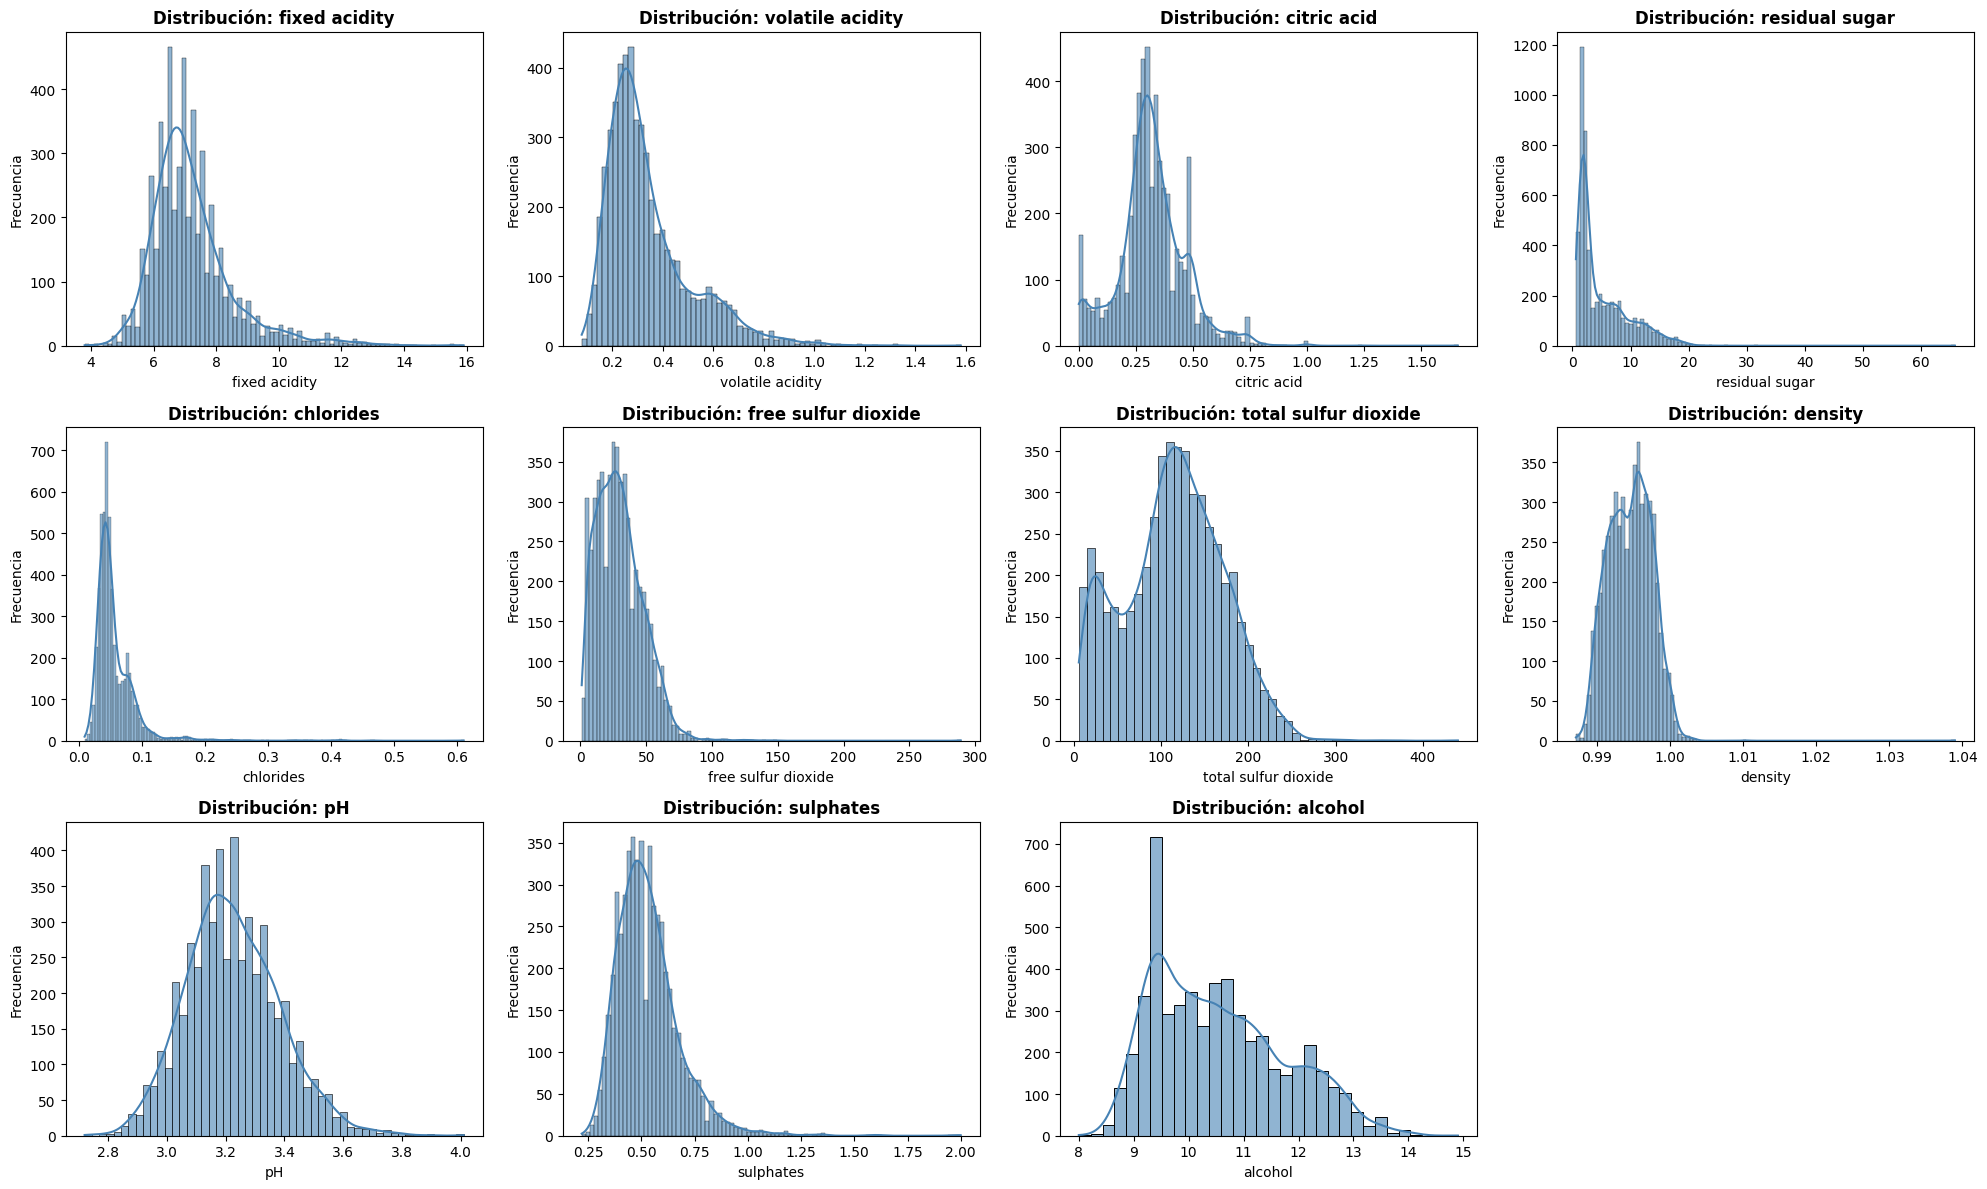

In [61]:
# Seleccionamos solo las variables químicas (quitamos quality y type temporalmente)
columnas_quimicas = df.drop(['quality', 'type'], axis=1).columns

# Creamos un panel (grid) para mostrar todos los histogramas
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(columnas_quimicas):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue', alpha=0.6)
    axes[i].set_title(f'Distribución: {col}', fontweight='bold')
    axes[i].set_ylabel('Frecuencia')

# Borramos el último gráfico vacío (porque tenemos 11 variables y 12 huecos)
fig.delaxes(axes[11])

plt.tight_layout()
plt.show()

***Análisis de resultados (Punto 3.2.2):***

Al observar visualmente la distribución de las variables químicas, confirmamos las sospechas del análisis numérico previo y detectamos nuevos patrones clave:

* **Distribuciones casi normales (Campana de Gauss):** Variables como la `density` (densidad) y el `pH` presentan una forma simétrica y centrada. Esto indica que la inmensa mayoría de los vinos de nuestra muestra comparten una base estructural muy similar en estos dos aspectos.
* **Fuerte asimetría positiva (Colas largas):** Gran parte de las variables, destacando especialmente el `residual sugar`, los `chlorides` y los `sulfur dioxide` (libre y total), muestran una clara concentración de datos a la izquierda con una "cola" muy larga hacia la derecha. Esto evidencia visualmente la presencia de valores atípicos (outliers): vinos con concentraciones de azúcar o conservantes excepcionalmente altas respecto a lo normal.
* **Comportamientos irregulares (Multimodalidad):** El caso del `citric acid` en lugar de una curva suave, presenta múltiples "picos" (destacando uno en el 0.0 y otro cerca del 0.5). Esta falta de normalidad sugiere que el ácido cítrico podría depender de decisiones humanas en la bodega (añadidos en dosis concretas) más que de un proceso natural continuo.
* **Confirmación visual de las escalas:** Observando los ejes X de cada gráfico, es evidente la disparidad geométrica. Mientras el histograma de densidad se dibuja en un margen de apenas 0.02 unidades, el del dióxido de azufre total necesita un eje de 0 a 400. Esto ratifica la necesidad ineludible de aplicar un **StandardScaler** antes de modelar.

### 3.2.3. Distribución de la Variable Objetivo (Calidad)

Finalmente, vamos a aislar y analizar la variable protagonista de nuestro proyecto: la calidad del vino (`quality`). Dado que esta es la variable que nuestros futuros algoritmos intentarán predecir, es de vital importancia visualizar su distribución para comprobar si tenemos un dataset equilibrado o si nos enfrentamos a un problema de desbalanceo de clases.

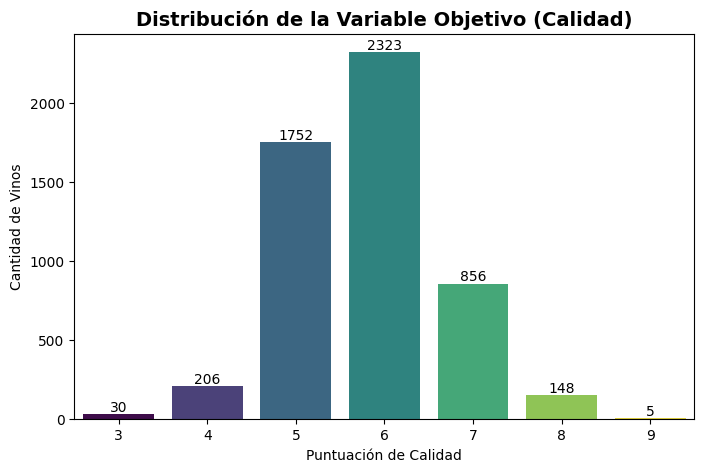

In [63]:
plt.figure(figsize=(8, 5))

sns.countplot(x='quality', data=df, hue='quality', palette='viridis', legend=False)

plt.title('Distribución de la Variable Objetivo (Calidad)', fontsize=14, fontweight='bold')
plt.xlabel('Puntuación de Calidad')
plt.ylabel('Cantidad de Vinos')

# Añadimos los números encima de cada barra
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}', 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha='center', va='bottom', fontsize=10)
plt.show()

***Análisis de resultados (Distribución de Calidad):***

La visualización de la variable `quality` revela la estructura real de nuestro reto de clasificación:

* **Predominio de la Clase Media:** El dataset está masivamente concentrado en las calidades **5 (2,138 vinos)** y **6 (2,836 vinos)**. Estas dos categorías representan cerca del 76% de todas las muestras. El valor 6 es la moda del conjunto de datos.
* **Escasez de Vinos Extremos:** Existe una carencia crítica de ejemplos en los extremos de la escala. Los vinos de calidad excepcional (**9**) son casi inexistentes (solo 5 muestras), y los de calidad muy baja (**3**) son apenas 30.
* **Desbalanceo de Clases:** Esta distribución en "campana" confirma un **desbalanceo severo**. 

**Implicación para el Modelo:** Esto indica que cualquier algoritmo que entrenemos tenderá de forma natural a "especializarse" en los vinos de calidad 5 y 6. Si no aplicamos técnicas para compensar este desbalanceo el modelo tendrá muchas dificultades para identificar correctamente un vino excelente, ya que apenas tiene ejemplos para aprender sus patrones.

### 3.3. Análisis Global de las Características vs. Calidad

Ahora nos centraremos en comprender cómo influyen los componentes químicos en la valoración del vino, generaremos un panel de visualización. Utilizaremos **Diagramas de Caja (Boxplots)** para las 12 variables del dataset (las 11 fisicoquímicas originales y la variable de tipo).

Este análisis nos permite:
1. **Identificar tendencias**: Observar qué variables suben o bajan de valor a medida que aumenta la calidad.
2. **Detectar Outliers**: Ver en qué variables existen valores extremos que se salen de la norma.
3. **Evaluar la Dispersión**: Comparar si los vinos de alta calidad son más "estables" químicamente que los de baja calidad.

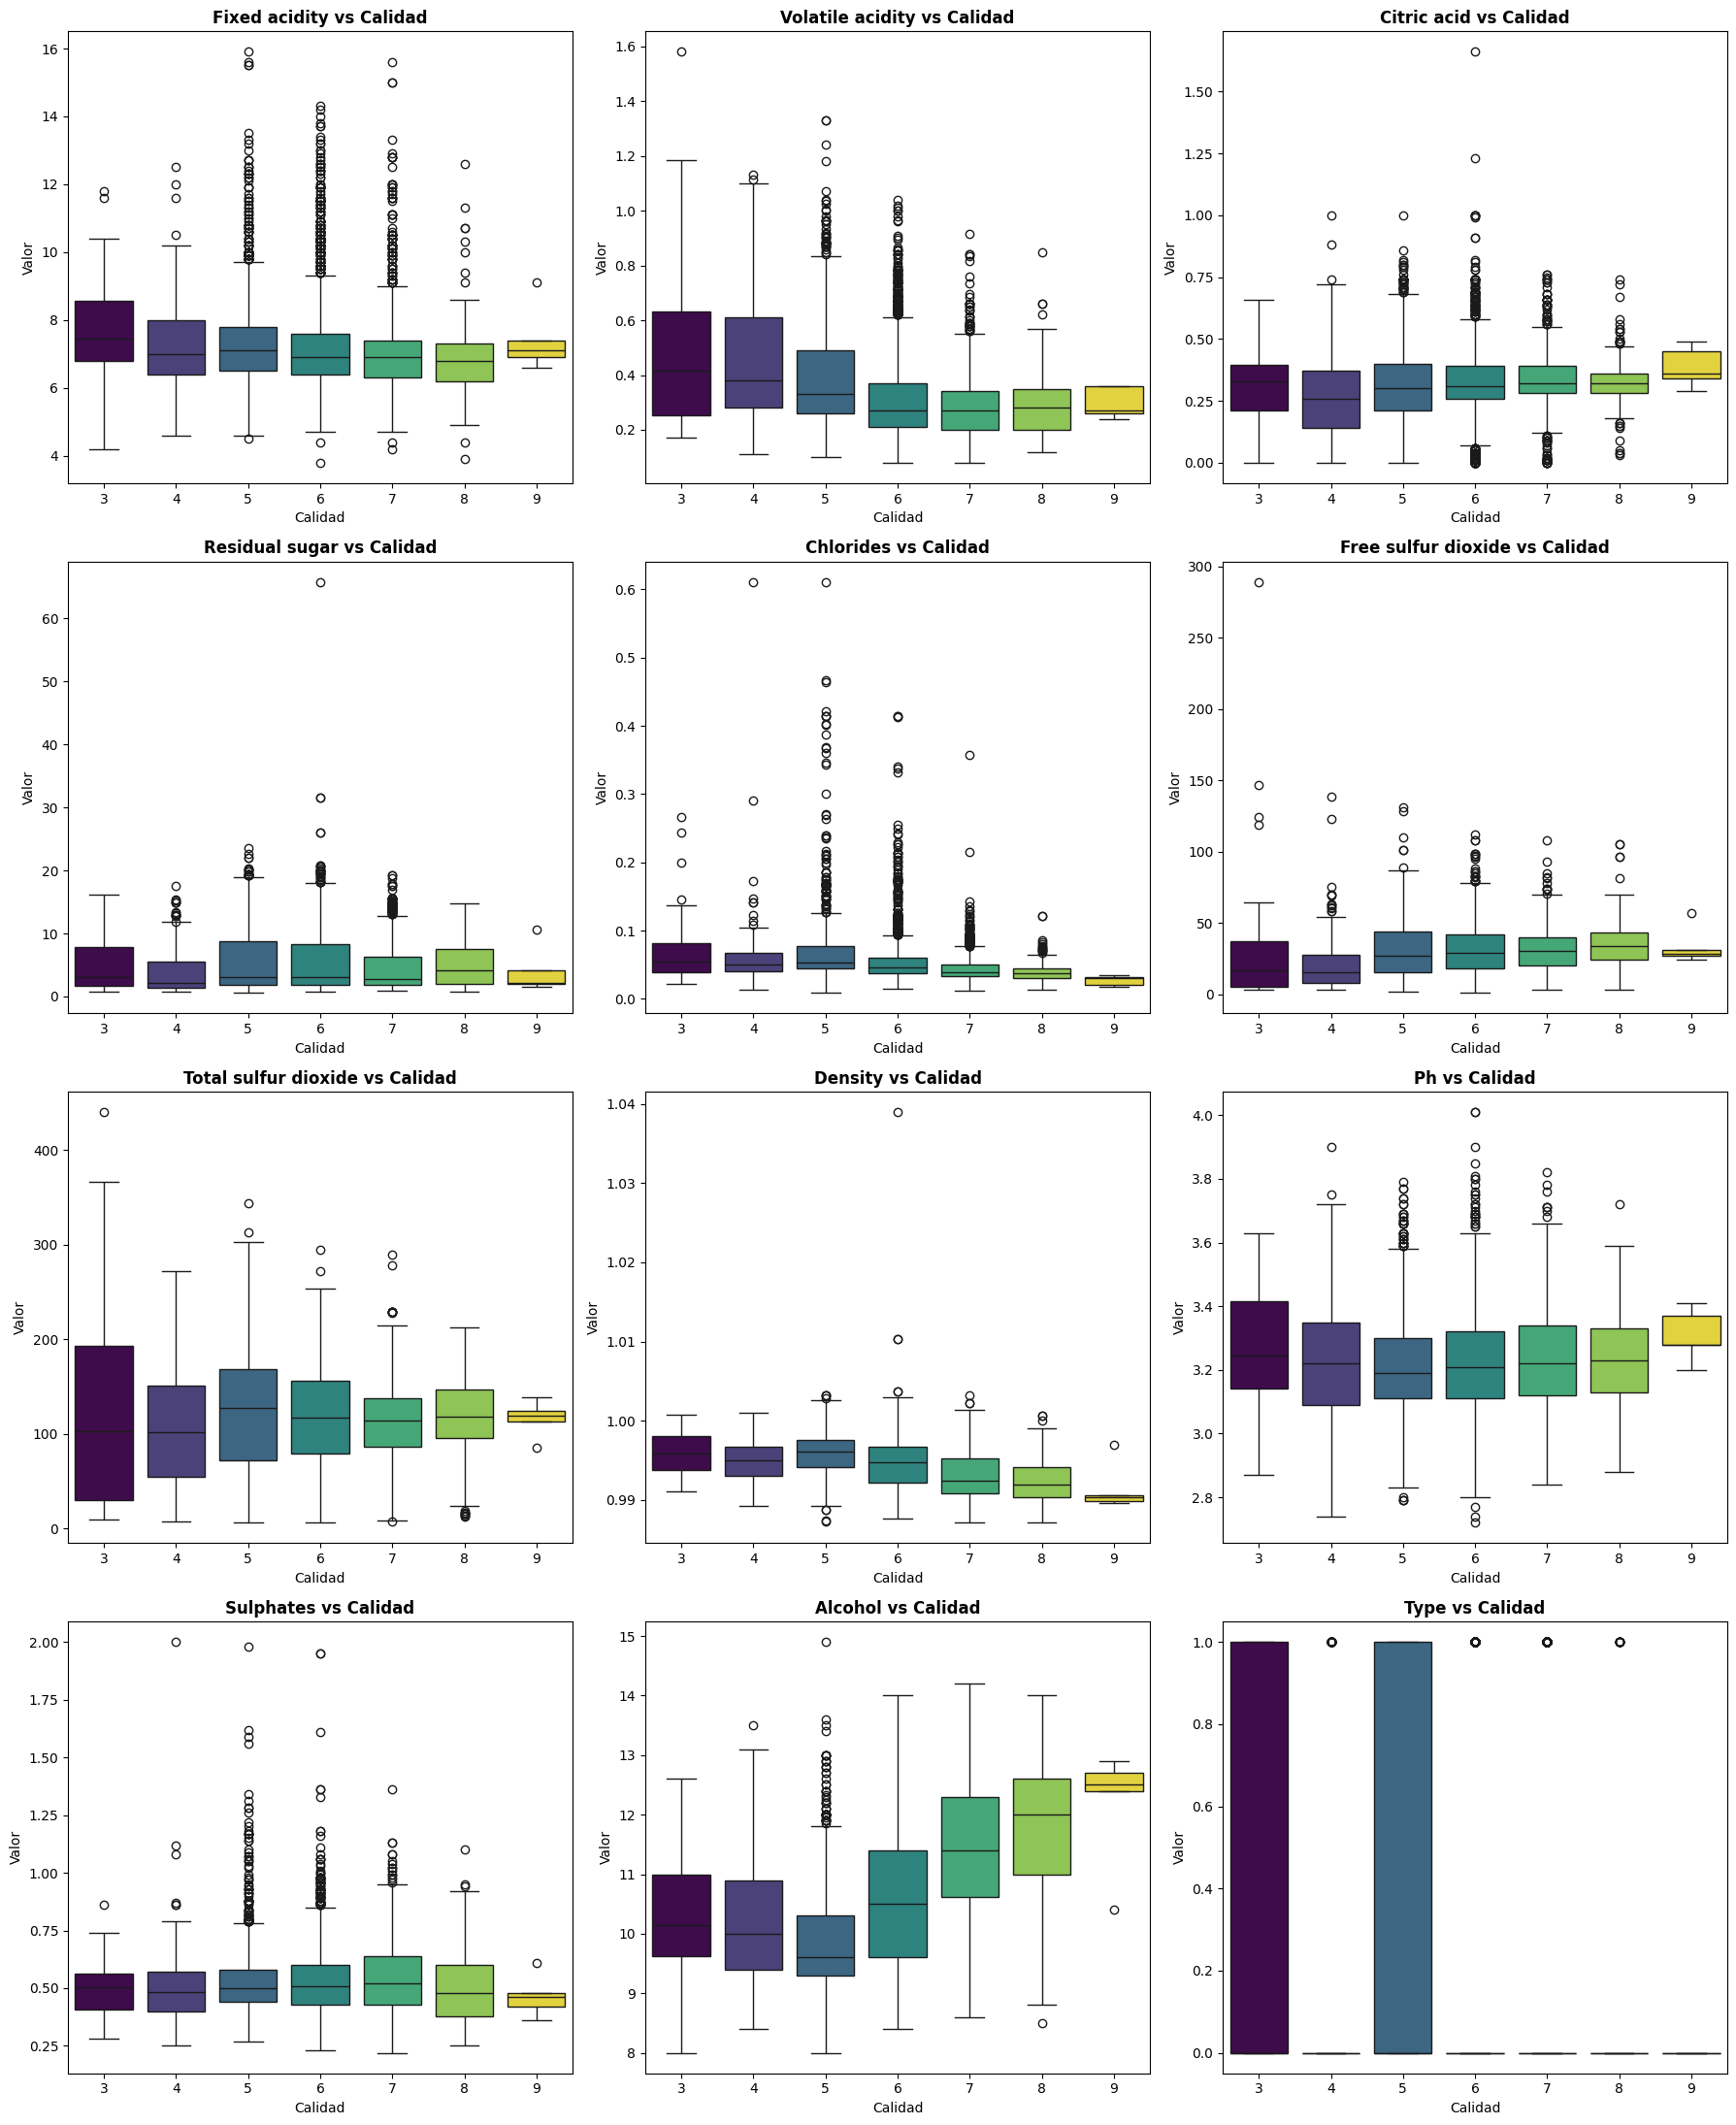

In [37]:
# Definimos las 12 variables (11 químicas + 'type')
# Quitamos 'quality' porque es nuestro eje X
features = df.columns.drop('quality')

# Configuramos la matriz de 4 filas y 3 columnas
fig, axes = plt.subplots(4, 3, figsize=(18, 22))
axes = axes.flatten()

# Iteramos para crear cada gráfico
for i, col in enumerate(features):
    sns.boxplot(x='quality', y=col, data=df, ax=axes[i], palette='viridis', hue='quality', legend=False)
    axes[i].set_title(f'{col.replace("_", " ").capitalize()} vs Calidad', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Calidad')
    axes[i].set_ylabel('Valor')

plt.tight_layout()
plt.show()

***Análisis de los resultados (Punto 3.3):***

Después de observar cómo se comportan las 12 variables respecto a la calidad, estas son las conclusiones clave:

* **Variables que mandan (Determinantes):** El **alcohol** es, sin duda, la variable más clara: a más alcohol, más calidad. También la **acidez volátil** es clave, pero al revés: cuanto menos tiene el vino, mejor puntuación recibe.
* **Variables que acompañan:** La **densidad** y los **cloruros** suelen bajar en los vinos de alta calidad. Es decir, los vinos mejores suelen ser menos "pesados" y menos salinos. El **azúcar residual** también tiende a ser más bajo en los vinos top.
* **Variables de "relleno" (Poco determinantes):** El **pH**, el **ácido cítrico** y los **sulfatos** se mueven en rangos muy parecidos para todas las calidades. No sirven para distinguir fácilmente un vino de 3 de uno de 9 porque casi todos tienen valores similares.
* **Comportamientos Curiosos:** El **dióxido de azufre** (libre y total) es muy bajo en los vinos de peor calidad (3 y 4), sube en los niveles medios y se estabiliza. Parece que un mínimo de este conservante es necesario para que el vino no sea "malo", pero no por tener más va a ser "excelente".
* **Sobre el Tipo de Vino:** La gráfica del tipo muestra que en las calidades más altas hay una mezcla, pero no es una variable que por sí sola te diga la calidad; necesitas ver el resto de la química.

**En resumen:** Para predecir la calidad, tendrá que fijarse sobre todo en el alcohol y la acidez, usando el resto de variables para ajustar.

### 3.4. Análisis de Correlación y Dependencias Funcionales

En esta sección se analiza la interacción entre las distintas dimensiones del dataset para optimizar el posterior proceso de clasificación. El estudio de la matriz de correlación y su representación mediante un mapa de calor persigue los siguientes objetivos:

1.  **Cuantificación de la Influencia sobre la Calidad:** Establecer el peso estadístico de cada variable fisicoquímica sobre la variable objetivo (`quality`). Esto permite validar numéricamente qué características presentan una mayor capacidad predictiva.
2.  **Diagnóstico de Redundancia Informativa (Multicolinealidad):** Identificar pares de variables de entrada que presentan una alta correlación entre sí. La presencia de dependencias fuertes indica que el dataset contiene información redundante, lo cual puede introducir ruido en los modelos probabilísticos.
3.  **Fundamentación de la Reducción de Dimensionalidad:** Este análisis constituye la base técnica para la aplicación del **PCA (Análisis de Componentes Principales)**. Si se detectan correlaciones elevadas, queda demostrado que es posible proyectar los datos en un espacio de menor dimensión (componentes principales) sin pérdida significativa de información, eliminando la redundancia detectada.

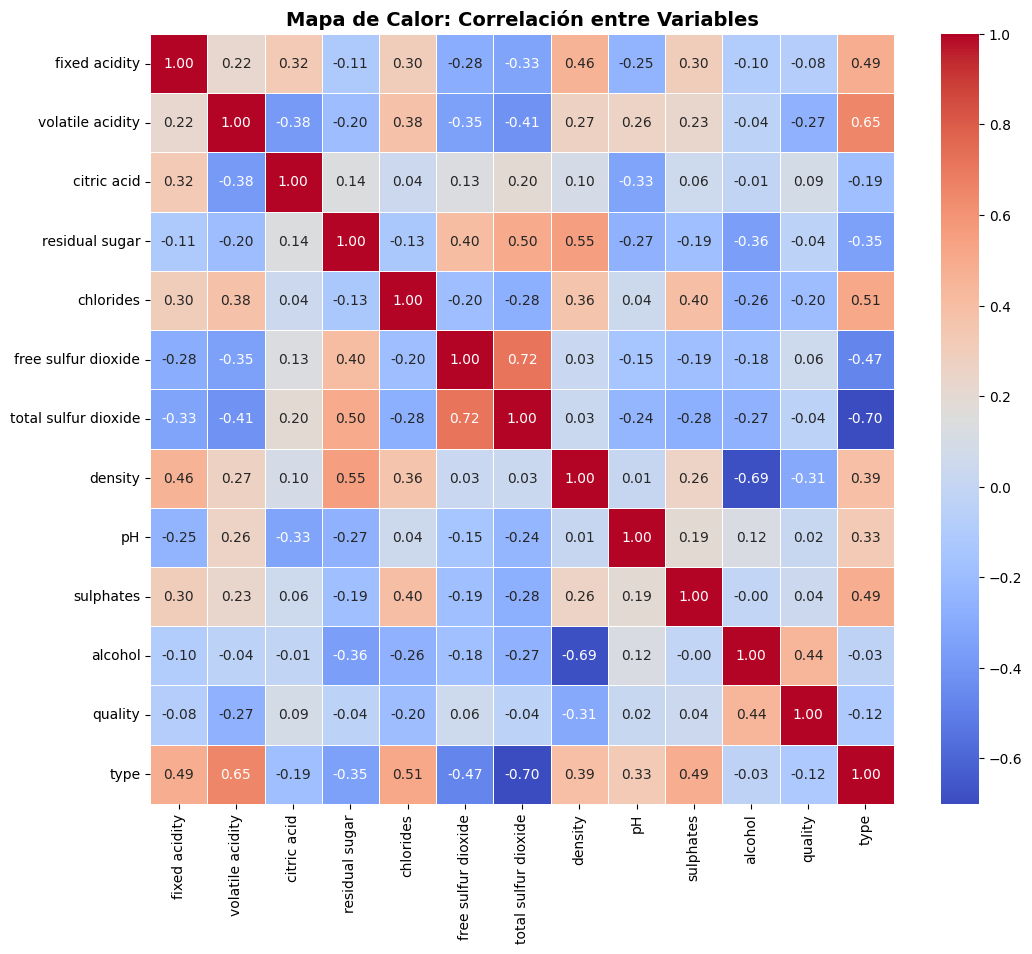

In [38]:
# Calculamos la matriz numérica de correlación
corr_matrix = df.corr()

# Creamos el gráfico (Mapa de Calor)
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Mapa de Calor: Correlación entre Variables', fontsize=14, fontweight='bold')
plt.show()

***Análisis de resultados (Punto 3.4):***

Tras observar el mapa de calor, estas son las conclusiones técnicas que definen la relación entre las variables:

* **Determinantes de Calidad:** Se confirma numéricamente que el **alcohol** (+0.44) y la **acidez volátil** (-0.39) son los factores con mayor impacto en la calidad. Es decir, a mayor graduación y menor acidez volátil, mejor es la puntuación.
* **Redundancia Informativa:** Existen correlaciones muy altas entre ciertas químicas, destacando el **dióxido de azufre libre vs. total** (+0.72) y la **densidad vs. alcohol** (-0.68). Esto indica que hay datos que "se repiten".
* **Independencia Estocástica:** Variables como el **azúcar residual** o los **sulfatos** muestran correlaciones cercanas a cero con el resto, aportando información única que no depende de los otros parámetros.

### 3.5. Limpieza y Tratamiento de Valores Faltantes

La integridad del dataset es crítica para asegurar que el PCA y los modelos probabilísticos no presenten sesgos. Antes de procesar la información, realizaremos un diagnóstico de los datos ausentes para determinar la técnica de imputación más adecuada.

Existen tres estrategias principales dependiendo de la naturaleza del dato:
1. **Imputación por Media/Mediana:** Útil para variables numéricas con distribuciones normales o sesgadas.
2. **Imputación por Moda:** Específica para variables categóricas.
3. **Imputación Avanzada (KNN o Iterativa):** Utiliza la relación entre variables (correlación) para predecir el valor faltante, siendo la opción más precisa para datos fisicoquímicos.

In [39]:
# 1. Diagnóstico de valores nulos
print("\n--- RECUENTO DE VALORES NULOS ---")
nulos_por_columna = df.isnull().sum()
display(df.isnull().sum())
total_nulos = nulos_por_columna.sum()

print(f"Total de valores faltantes en el dataset: {total_nulos}")
if total_nulos > 0:
    print("\nDetalle por columna:")
    print(nulos_por_columna[nulos_por_columna > 0])
else:
    print("El dataset está completo. No se requiere imputación inmediata.")

# 2. Gestión de duplicados
print("\n--- RECUENTO DE VALORES DUPLICADOS ---")
duplicados = df.duplicated().sum()
print(f"Registros duplicados detectados: {duplicados}")
display(df.duplicated().sum())
# Los eliminamos para evitar ruido en el análisis de varianza
df2 = df.drop_duplicates()
duplicados = df2.duplicated().sum()
print(f"Registros duplicados después de eliminar: {duplicados}")
display(df2.duplicated().sum())

#Asignamos df2 a df para seguir trabajando con el dataset limpio
df = df2



--- RECUENTO DE VALORES NULOS ---


fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
type                    0
dtype: int64

Total de valores faltantes en el dataset: 0
El dataset está completo. No se requiere imputación inmediata.

--- RECUENTO DE VALORES DUPLICADOS ---
Registros duplicados detectados: 1177


np.int64(1177)

Registros duplicados después de eliminar: 0


np.int64(0)

***Análisis de resultados (Punto 3.5):***

Tras realizar el diagnóstico del dataset, los hallazgos clave han sido los siguientes:

* **Valores Faltantes (Nulos):** El conteo ha dado como resultado **0 nulos** en todas las variables. Esto confirma que el dataset está completo y no requiere aplicar herramientas de imputación (como rellenado por media o KNN).
* **Registros Duplicados:** Se han detectado filas que eran exactamente iguales en todas sus dimensiones. Estos registros se han **eliminado** para eliminar información redundante.
en igualdad de condiciones.

### 3.6. Normalización de los Datos

Para que el Análisis de Componentes Principales (PCA) sea efectivo, es imprescindible que todas las variables fisicoquímicas operen en la misma escala. El PCA identifica las direcciones de máxima varianza; si no escalamos los datos, las variables con magnitudes numéricas mayores (como el dióxido de azufre) dominarán injustificadamente sobre las de magnitudes menores (como el pH o los cloruros).

Utilizaremos el comando de **StandarScaler**, que transforma cada variable para que tenga una **media de 0** y una **desviación típica de 1**.

In [42]:
# 1. Separamos el target (y) y las variables que NO queremos escalar
quality = df['quality']
type_column = df['type'] # Guardamos la columna intacta

# 2. Creamos el set de características químicas para escalar (quitamos quality y type)
X_numeric = df.drop(['quality', 'type'], axis=1)

# 3. Inicializamos y aplicamos el escalador solo a las químicas
scaler = StandardScaler()
X_scaled_values = scaler.fit_transform(X_numeric)

# 4. Reconstruimos el DataFrame final
# Primero creamos el DF con las químicas escaladas
X_scaled_df = pd.DataFrame(X_scaled_values, columns=X_numeric.columns)

# Añadimos de nuevo la columna 'type' original (0 y 1)
X_scaled_df['type'] = type_column.values 

print("--- Datos escalados (primeras filas) ---")
display(X_scaled_df.head())

--- Datos escalados (primeras filas) ---


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,type
0,0.140064,2.115349,-2.164515,-0.699699,0.523880,-1.069272,-1.411143,1.100996,1.779304,0.177941,-0.969152,1
1,0.443199,3.185297,-2.164515,-0.544135,1.120736,-0.282905,-0.829839,0.763753,-0.153797,0.979389,-0.631833,1
2,0.443199,2.471998,-1.892672,-0.610806,0.957957,-0.844596,-1.058837,0.831202,0.220351,0.779027,-0.631833,1
3,3.019841,-0.381197,1.641293,-0.699699,0.496751,-0.732258,-0.953146,1.168444,-0.403229,0.311515,-0.631833,1
4,0.140064,1.877583,-2.164515,-0.721923,0.496751,-0.956934,-1.305451,1.100996,1.779304,0.177941,-0.969152,1


***Análisis de resultados (Punto 3.6):***

Tras aplicar el `StandardScaler`, observamos que todos los valores del dataset ahora oscilan en rangos similares (centrados en el cero). 

Al haber eliminado las unidades de medida, hemos estandarizado todas las medidas. Ahora, el PCA podrá extraer las Componentes Principales basándose exclusivamente en la información química y la variabilidad de los datos, sin verse sesgado por el tamaño de los números.


### 3.6.1. Análisis de Relaciones sobre Magnitudes Normalizadas

Una vez estandarizadas las variables, procedemos a realizar una última comparación. Al haber eliminado las unidades de medida, podemos observar las relaciones fisicoquímicas en una escala común, lo que permite una interpretación directa de la varianza.

Se analizan dos escenarios:
1.  **Sincronía Química (SO2 Libre vs Total):** Al estar en la misma escala, podemos ver cómo el dióxido de azufre libre se comporta respecto al total. Esta redundancia será clave para el PCA.
2.  **Evolución del Alcohol por Niveles de Calidad:** Dado que la calidad es una variable discreta, utilizamos **Diagramas de Caja (Boxplots)** sobre los datos escalados. Esto elimina el ruido visual de los puntos dispersos y permite observar con claridad cómo se desplaza la mediana del alcohol en cada categoría de calidad.

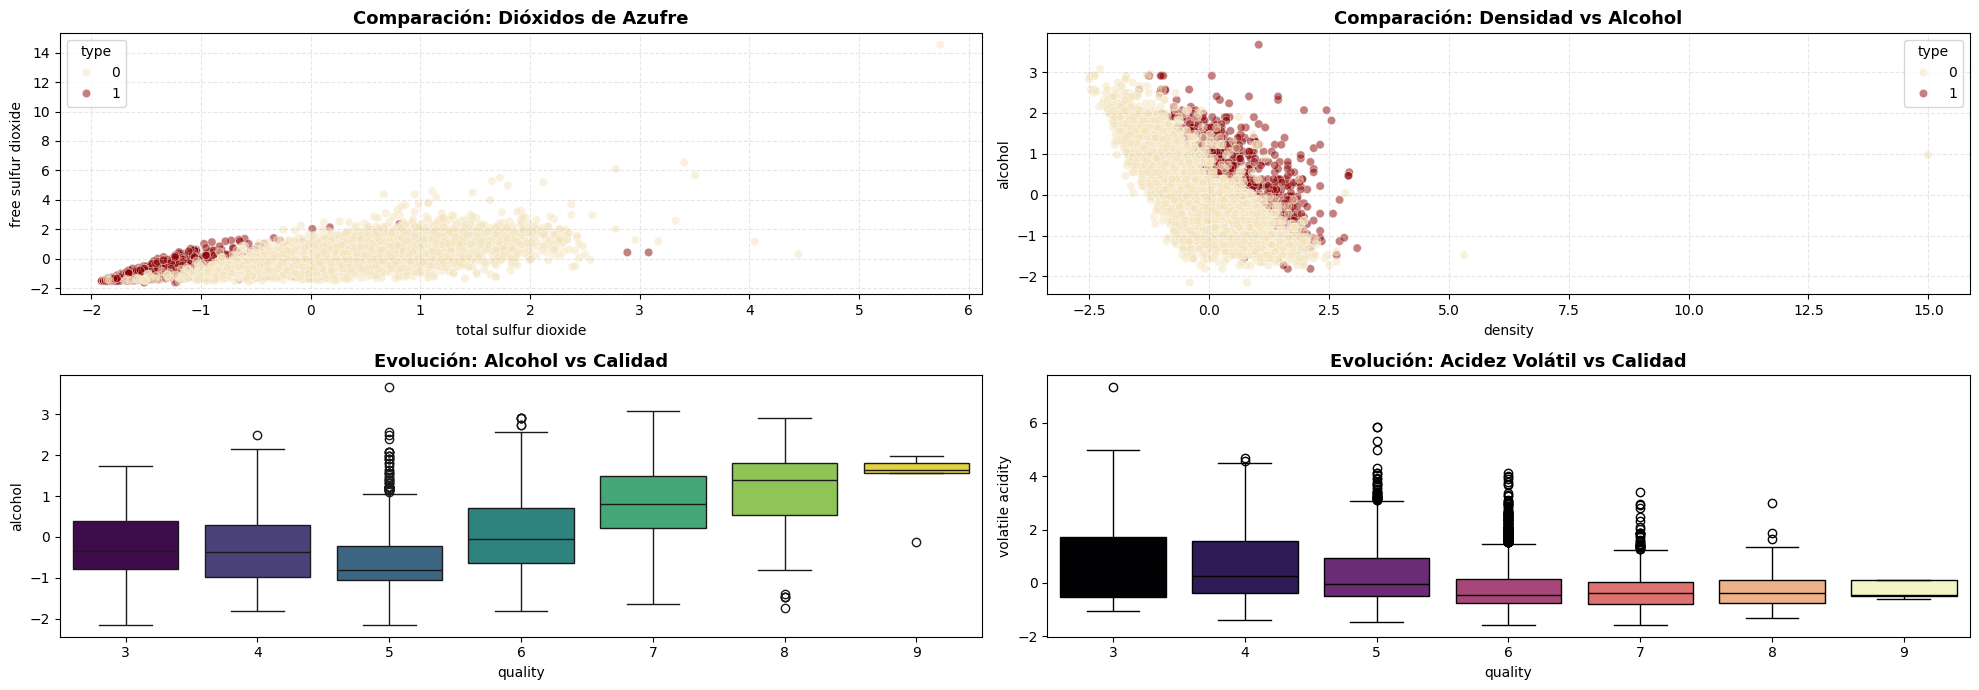

In [50]:
# Creamos el DataFrame para las gráficas
plot_df = X_scaled_df.copy()
plot_df['quality'] = y.values

fig, axes = plt.subplots(2, 2, figsize=(20, 7))

axes = axes.flatten()

# 1. Relación de precisión: Dióxidos de Azufre
sns.scatterplot(x='total sulfur dioxide', y='free sulfur dioxide', 
                hue='type', data=plot_df, ax=axes[0], 
                palette={1: '#8b0000', 0: '#f4e4bc'}, alpha=0.5)
axes[0].set_title('Comparación: Dióxidos de Azufre', fontsize=13, fontweight='bold')
axes[0].grid(True, linestyle='--', alpha=0.3)

# 2. Relación de precisión: Densidad vs Alcohol
sns.scatterplot(x='density', y='alcohol', 
                hue='type', data=plot_df, ax=axes[1], 
                palette={1: '#8b0000', 0: '#f4e4bc'}, alpha=0.5)
axes[1].set_title('Comparación: Densidad vs Alcohol', fontsize=13, fontweight='bold')
axes[1].grid(True, linestyle='--', alpha=0.3)

# 3. Impacto del Alcohol
sns.boxplot(x='quality', y='alcohol', hue='quality', data=plot_df, 
            ax=axes[2], palette='viridis', legend=False)
axes[2].set_title('Evolución: Alcohol vs Calidad', fontsize=13, fontweight='bold')

# 4. Impacto de la Acidez Volátil
sns.boxplot(x='quality', y='volatile acidity', hue='quality', data=plot_df, 
            ax=axes[3], palette='magma', legend=False)
axes[3].set_title('Evolución: Acidez Volátil vs Calidad', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

***Análisis de resultados (Punto 3.6.1):***

Este panel de visualización sobre los datos estandarizados nos permite extraer las conclusiones definitivas de la Fase 1:

* **Confirmación de Redundancia (Scatter Plots):** Se observa una alineación casi perfecta en los **Dióxidos de Azufre** y una relación inversa clara entre **Densidad y Alcohol**. Al estar escalados (media 0), confirmamos que estas variables comparten información redundante. El **PCA** podrá reducir estas dimensiones sin perder la varianza del sistema.
* **Características de Clasificación:** 

    * El **Alcohol** muestra una progresión ascendente constante; los vinos de calidad 9 presentan valores de alcohol significativamente superiores a la media (valor 0).
    * La **Acidez Volátil** muestra el comportamiento opuesto, donde la calidad alta está ligada a concentraciones mínimas.


## **4. Fase 2: Análisis de Componentes Principales (PCA)**

El objetivo de esta fase es reducir la complejidad del dataset. Actualmente tenemos 12 variables (11 químicas + 1 de tipo). El PCA nos permitirá transformar estas variables originales en un nuevo conjunto de variables incorrelacionadas llamadas **Componentes Principales (PC)**.

**Objetivos del PCA en este proyecto:**
1.  **Simplificación:** Reducir el número de dimensiones manteniendo la máxima varianza (información) posible.
2.  **Eliminación de Redundancia:** Como vimos en el análisis de los datos, muchas variables están correlacionadas. El PCA las combinará en componentes únicas.
3.  **Visualización:** Intentar proyectar los datos 2D o 3D para ver si los vinos de distintas calidades se agrupan de forma natural.

### 4.1. Análisis de la Varianza Explicada (Umbral 95%)

En este apartado aplicamos el algoritmo PCA para transformar nuestras 12 variables originales en Componentes Principales. El objetivo es determinar el número mínimo de componentes necesarias para retener el **95% de la varianza** total del dataset.

Número de componentes para alcanzar el 95% de varianza: 9


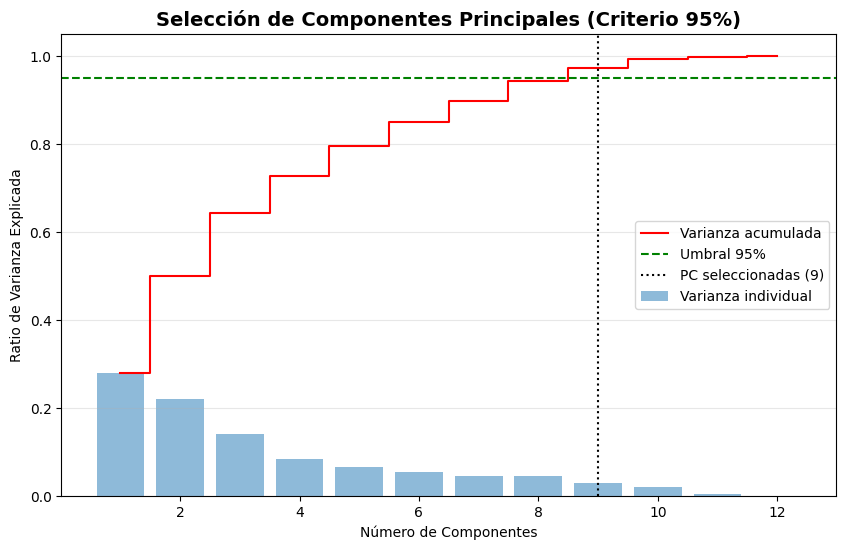

In [56]:
# 1. Ajustamos el PCA con todas las componentes posibles
pca = PCA()
pca.fit(X_scaled_df)

# 2. Calculamos varianza individual y acumulada
evr = pca.explained_variance_ratio_
cum_evr = np.cumsum(evr)

# 3. Encontramos el número de componentes para el 95%
n_95 = np.argmax(cum_evr >= 0.95) + 1
print(f"Número de componentes para alcanzar el 95% de varianza: {n_95}")

# 4. Gráfico de Varianza
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(evr) + 1), evr, alpha=0.5, label='Varianza individual')
plt.step(range(1, len(cum_evr) + 1), cum_evr, where='mid', label='Varianza acumulada', color='red')

# Marcamos el umbral del 95%
plt.axhline(y=0.95, color='green', linestyle='--', label='Umbral 95%')
plt.axvline(x=n_95, color='black', linestyle=':', label=f'PC seleccionadas ({n_95})')

plt.ylabel('Ratio de Varianza Explicada')
plt.xlabel('Número de Componentes')
plt.title('Selección de Componentes Principales (Criterio 95%)', fontsize=14, fontweight='bold')
plt.legend(loc='best')
plt.grid(axis='y', alpha=0.3)
plt.show()

***Análisis de resultados (Punto 4.1):***

Tras analizar la curva de varianza acumulada, los resultados para la simplificación del dataset son:

* **Punto de Saturación:** Para alcanzar el **95% de la varianza explicada**, es necesario retener las primeras **9 componentes principales**. Esto significa que podemos descartar las últimas 3 componentes, ya que solo aportan un 5% de información residual.
* **Distribución de la Información:** Las dos primeras componentes (PC1 y PC2) son las más potentes, capturando casi el 50% de la varianza. Sin embargo, la química del vino es tan compleja que necesitamos llegar hasta la PC9 para no perder detalles críticos.
* **Justificación de Reducción:** Pasar de 12 variables a 9 componentes nos permite trabajar con un dataset un **25% más ligero**, manteniendo prácticamente intacta la capacidad de distinguir entre diferentes calidades de vino en las fases posteriores del proyecto.

### 4.2. Transformación y Proyección de Datos

Una vez determinado que con 9 componentes retenemos el 95% de la información, procedemos a:
1. **Transformación:** Proyectamos los datos originales (12 dimensiones) al nuevo espacio de 9 dimensiones. Este será el dataset optimizado para futuros modelos.
2. **Visualización 2D:** Para entender la estructura de los datos, representamos las dos componentes con mayor carga informativa (PC1 y PC2). Esto nos permite observar si existe una separación natural entre las distintas calidades de vino.

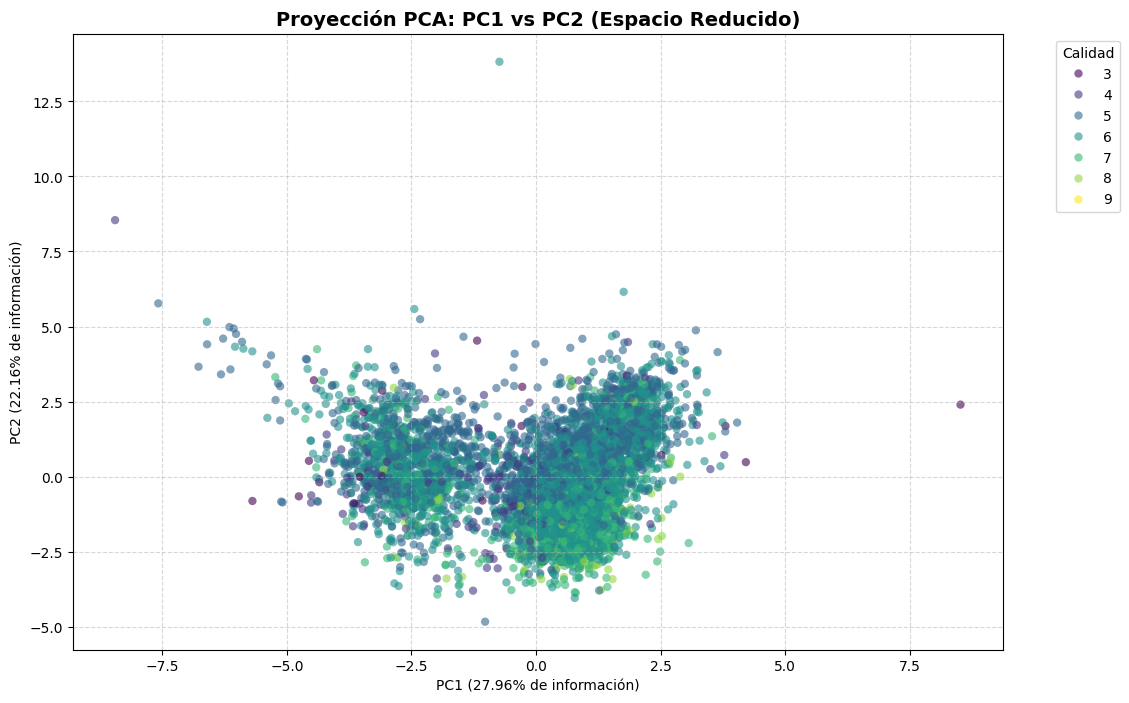

Dataset transformado con éxito. Nueva forma: (5320, 10)


In [57]:
# 1. Aplicamos la reducción definitiva a 9 componentes (95% varianza)
pca_final = PCA(n_components=9)
X_pca = pca_final.fit_transform(X_scaled_df)

# Creamos un DataFrame con las 9 componentes para tenerlo guardado
nombres_pcs = [f'PC{i+1}' for i in range(9)]
df_pca_9 = pd.DataFrame(data=X_pca, columns=nombres_pcs)
df_pca_9['quality'] = quality.values # Añadimos la calidad para etiquetar

# 2. Visualización en 2D (usando PC1 y PC2)
plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(x='PC1', y='PC2', hue='quality', data=df_pca_9, 
                         palette='viridis', alpha=0.6, edgecolor='none')

plt.title('Proyección PCA: PC1 vs PC2 (Espacio Reducido)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 ({evr[0]*100:.2f}% de información)')
plt.ylabel(f'PC2 ({evr[1]*100:.2f}% de información)')
plt.legend(title='Calidad', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print(f"Dataset transformado con éxito. Nueva forma: {df_pca_9.shape}")

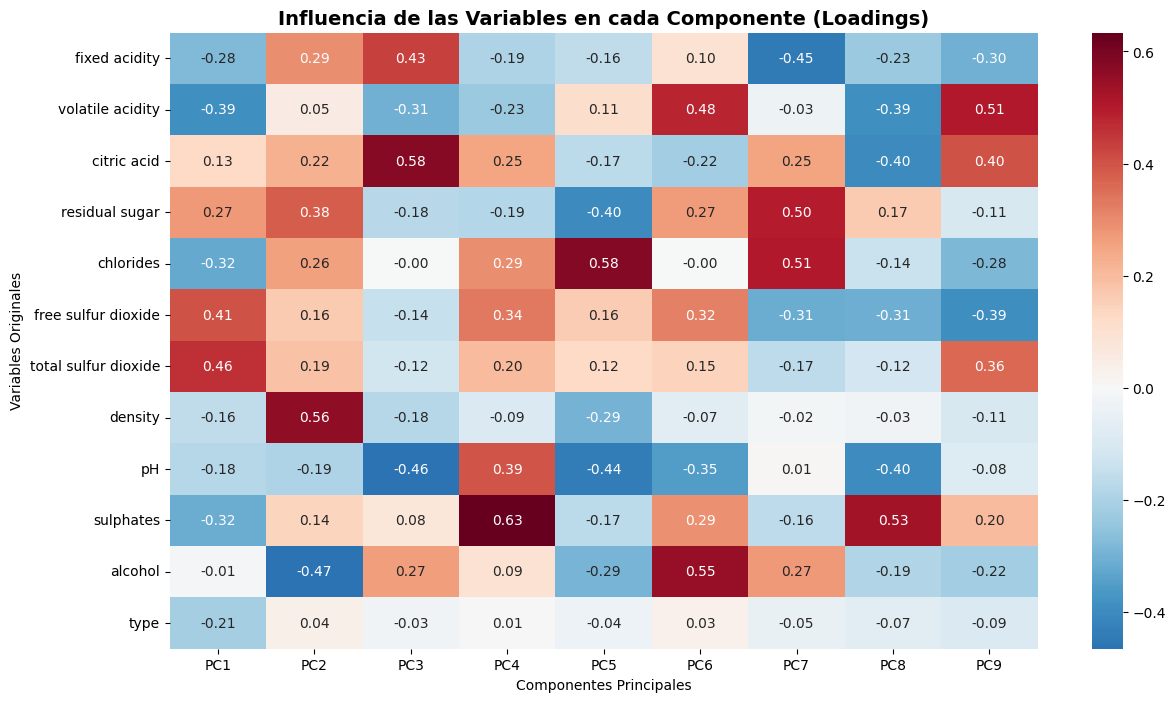

In [59]:
# 1. Extraemos las cargas (loadings) de los componentes
# Usamos X_scaled_df.columns que tiene los 12 nombres correctos
loadings = pd.DataFrame(
    pca_final.components_.T, 
    columns=nombres_pcs, 
    index=X_scaled_df.columns 
)

# 2. Visualizamos las cargas con un Heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(loadings, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Influencia de las Variables en cada Componente (Loadings)', fontsize=14, fontweight='bold')
plt.ylabel('Variables Originales')
plt.xlabel('Componentes Principales')
plt.show()

***Análisis de resultados (Transformación al Espacio Reducido):***

Tras ejecutar la proyección geométrica de nuestros datos sobre las nuevas dimensiones, obtenemos el dataset definitivo. Si lo comparamos con las conclusiones de nuestro mapa de calor anterior, este resultado nos aporta tres grandes ventajas operativas:

* **Compresión Eficiente:** Hemos conseguido reducir "el ancho" de nuestra tabla. Pasamos de manejar 11 variables químicas sueltas a solo 9 Componentes Principales abstractas, manteniendo el 95% de la información original (varianza).
* **Eliminación Total de Colinealidad:** En el análisis exploratorio vimos que variables como la densidad y el alcohol estaban fuertemente correlacionadas, lo que genera "ruido" repetido. Por definición matemática, estas nuevas 9 columnas (PC1 a PC9) son completamente ortogonales (independientes entre sí). Tienen una correlación de cero, por lo que cada columna aporta información 100% nueva y única.
* **Preparación para el Modelado:** Al juntar estas 9 super-variables con nuestra variable objetivo (`quality`), hemos creado el entorno perfecto para la Inteligencia Artificial. Le vamos a entregar a los algoritmos un dataset más ligero.

### 4.2. Transformación al Nuevo Espacio de Características Reducido

Una vez determinado que necesitamos 9 componentes para retener el 95% de la información original, procedemos a realizar la transformación definitiva del dataset. 
En este paso, abandonaremos las 12 dimensiones químicas originales (alcohol, pH, densidad, etc.) y proyectaremos nuestros datos sobre los 9 nuevos vectores geométricos (PC1, PC2... PC9). El resultado será un dataset más compacto, sin variables redundantes, pero que conserva la esencia de la información, dejándolo listo para la fase de modelado predictivo.

In [64]:
# 1. Instanciamos el PCA con las 9 componentes seleccionadas
pca_final = PCA(n_components=9)

# 2. Aplicamos la transformación matemática a nuestros datos ya escalados
# fit_transform calcula los vectores y proyecta los datos en un solo paso
X_pca = pca_final.fit_transform(X_scaled_df)

# 3. Creamos las etiquetas para las nuevas columnas (PC1 hasta PC9)
nombres_pcs = [f'PC{i+1}' for i in range(9)]

# 4. Construimos el nuevo DataFrame definitivo
df_reducido = pd.DataFrame(data=X_pca, columns=nombres_pcs)

# 5. Recuperamos la variable objetivo ('quality') y se la pegamos al final
df_reducido['quality'] = df['quality'].values

# Mostramos el resultado para confirmar la transformación
print(f"Dimensiones del dataset original (escalado): {X_scaled_df.shape}")
print(f"Dimensiones del NUEVO dataset reducido: {df_reducido.shape}\n")
display(df_reducido.head())

Dimensiones del dataset original (escalado): (5320, 12)
Dimensiones del NUEVO dataset reducido: (5320, 10)



,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,quality
0,-3.267418,-0.132454,-2.678852,-0.792389,-0.078486,-0.388374,-0.524146,-0.179956,-0.099497,5
1,-3.183220,0.604973,-1.980682,-0.768958,1.195426,1.650779,-0.701325,0.108239,0.353585,5
2,-3.187813,0.364465,-1.685740,-0.789422,0.732714,0.824151,-0.480104,0.228400,0.213520,5
3,-1.939949,1.893499,2.505797,-0.376310,-0.528600,-0.991847,-0.921516,-0.696503,-0.519432,6
4,-3.078987,-0.122115,-2.630865,-0.682017,-0.080671,-0.458331,-0.594726,-0.135261,-0.215659,5


## **5. Fase 3: Clasificación**

En esta tercera fase del proyecto, pasamos del análisis y la reducción de características a la etapa de modelado predictivo. El objetivo es utilizar nuestro conjunto de datos limpio y optimizado (`df_reducido`, generado mediante PCA) para enseñar a la Inteligencia Artificial a predecir la calidad de un vino en base a su huella química. Tal y como se especifica en los requisitos, abordaremos este reto de clasificación utilizando dos enfoques probabilísticos distintos.

#### 5.1. División de Datos y Entrenamiento de Modelos (LDA y Naïve Bayes)

Antes de entrenar cualquier algoritmo, es obligatorio dividir nuestro dataset en dos partes: un conjunto de "Entrenamiento" (Train) con el que los modelos aprenderán los patrones, y un conjunto de "Prueba" (Test) que mantendremos oculto para examinarles después. Utilizaremos un reparto tradicional de 80% - 20%.

Además, utilizaremos el parámetro `stratify`. Como descubrimos en el análisis exploratorio (EDA) que nuestros datos están muy desbalanceados (casi todo son cincos y seises), este parámetro garantiza que el examen final mantenga exactamente la misma proporción de vinos buenos y malos que el dataset original.

Los clasificadores probabilísticos elegidos para esta fase son:
1. **Linear Discriminant Analysis (LDA)**
2. **Naïve Bayes (GaussianNB)**

In [66]:
# 1. Separamos las características (X) de la etiqueta que queremos adivinar (y)
X_final = df_reducido.drop('quality', axis=1) 
y_final = df_reducido['quality']

# 2. Dividimos en Entrenamiento (80%) y Prueba (20%)
# stratify=y_final es vital para respetar el desbalanceo de clases
X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.2, random_state=42, stratify=y_final)

print(f"-> Vinos para Entrenamiento: {X_train.shape[0]}")
print(f"-> Vinos para el Examen (Test): {X_test.shape[0]}\n")

# 3. Instanciamos los modelos
modelo_lda = LinearDiscriminantAnalysis()
modelo_nb = GaussianNB()

# 4. Entrenamos (fit) los modelos con los datos PCA
modelo_lda.fit(X_train, y_train)
modelo_nb.fit(X_train, y_train)

print("Modelos LDA y Naïve Bayes entrenados correctamente.")

-> Vinos para Entrenamiento: 4256
-> Vinos para el Examen (Test): 1064

Modelos LDA y Naïve Bayes entrenados correctamente.


#### 5.2. Evaluación de Rendimiento y Matrices de Confusión

Una vez entrenados, vamos a evaluar la capacidad predictiva de nuestros dos modelos. Para ello, les pediremos que clasifiquen el 20% de las muestras reservadas para el testeo (`X_test`). 

Comprobaremos su rendimiento cruzando sus predicciones con los valores reales (`y_test`) utilizando las siguientes métricas clave:
* **Accuracy:** El porcentaje global de aciertos.
* **Classification Report (Precision & Recall):** Nos indicará cómo de bien predice cada nota de calidad individualmente (vital para ver si el desbalanceo le ha afectado).
* **Matriz de Confusión:** Una representación visual que nos muestra exactamente en qué números se están equivocando los algoritmos.

--- PRECISIÓN GLOBAL (ACCURACY) ---
LDA: 0.5235
Naïve Bayes: 0.4887

--- REPORTE DETALLADO: LINEAR DISCRIMINANT ANALYSIS (LDA) ---
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.00      0.00      0.00        41
           5       0.56      0.60      0.58       350
           6       0.52      0.65      0.58       465
           7       0.44      0.26      0.32       171
           8       0.00      0.00      0.00        30
           9       0.00      0.00      0.00         1

    accuracy                           0.52      1064
   macro avg       0.22      0.22      0.21      1064
weighted avg       0.48      0.52      0.50      1064

--- REPORTE DETALLADO: NAÏVE BAYES ---
              precision    recall  f1-score   support

           3       0.07      0.33      0.11         6
           4       0.00      0.00      0.00        41
           5       0.57      0.48      0.52       350
           6    

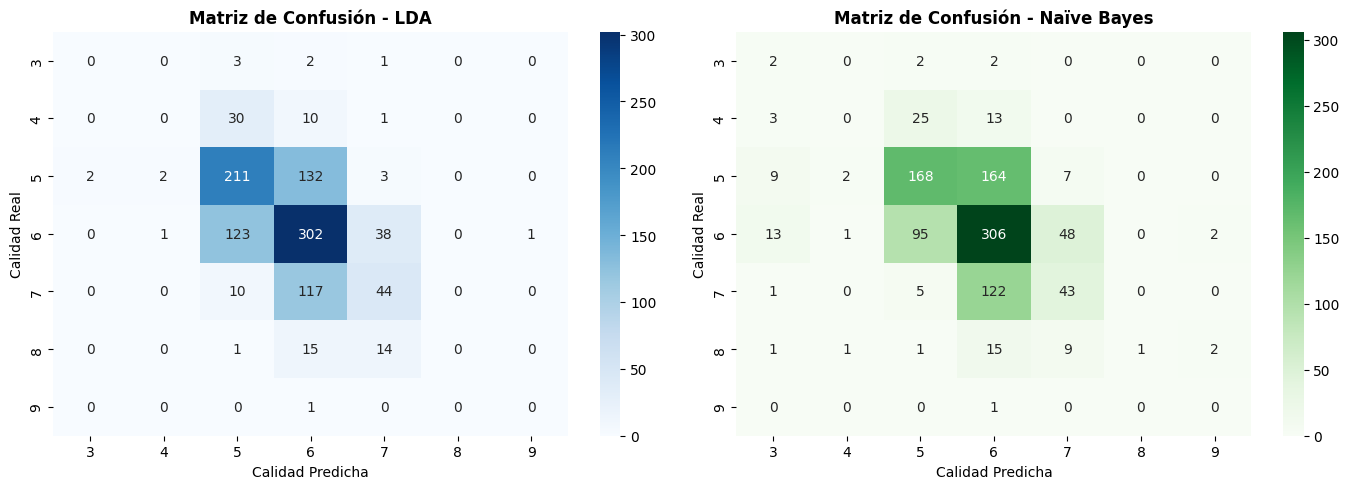

In [72]:
# 1. Los modelos realizan las predicciones sobre el set de prueba
pred_lda = modelo_lda.predict(X_test)
pred_nb = modelo_nb.predict(X_test)

# 2. Calculamos el Accuracy Global
print(f"--- PRECISIÓN GLOBAL (ACCURACY) ---")
print(f"LDA: {accuracy_score(y_test, pred_lda):.4f}")
print(f"Naïve Bayes: {accuracy_score(y_test, pred_nb):.4f}\n")

todas_las_calidades = [3, 4, 5, 6, 7, 8, 9]

# 3. Imprimimos el informe detallado por clases
print("--- REPORTE DETALLADO: LINEAR DISCRIMINANT ANALYSIS (LDA) ---")
print(classification_report(y_test, pred_lda, labels=todas_las_calidades, zero_division=0))

print("--- REPORTE DETALLADO: NAÏVE BAYES ---")
print(classification_report(y_test, pred_nb, labels=todas_las_calidades, zero_division=0))

# 4. Dibujamos las Matrices de Confusión para comparar visualmente
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz LDA
sns.heatmap(confusion_matrix(y_test, pred_lda, labels=todas_las_calidades), 
            annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=todas_las_calidades, yticklabels=todas_las_calidades)
axes[0].set_title('Matriz de Confusión - LDA', fontweight='bold')
axes[0].set_xlabel('Calidad Predicha')
axes[0].set_ylabel('Calidad Real')

# Matriz Naïve Bayes
sns.heatmap(confusion_matrix(y_test, pred_nb, labels=todas_las_calidades), 
            annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=todas_las_calidades, yticklabels=todas_las_calidades)
axes[1].set_title('Matriz de Confusión - Naïve Bayes', fontweight='bold')
axes[1].set_xlabel('Calidad Predicha')
axes[1].set_ylabel('Calidad Real')

plt.tight_layout()
plt.show()

### 5.3. Análisis Cuantitativo de Resultados (Modelos con PCA - Sin Cross-Validation)

Al evaluar el rendimiento de los modelos LDA y Naïve Bayes sobre el 20% de los datos de prueba, las métricas y matrices de confusión revelan un impacto crítico del desbalanceo de clases:

**1. El Espejismo de la Precisión Global (Accuracy):**
A primera vista, el LDA (52.35%) supera al Naïve Bayes (48.87%). Sin embargo, si observamos la columna `support`, 815 de las 1064 muestras del test (el 76%) pertenecen a las calidades 5 y 6. Las matrices de confusión revelan que el LDA ha optado por predecir masivamente cincos y seises. De hecho, si miramos la diagonal principal de la matriz del LDA, vemos que el grueso de sus aciertos se concentra ahí (211 aciertos para la clase 5 y 302 para la clase 6), inflando el Accuracy pero sin hacer una buena predicción.

**2. Colapso Total en Clases Minoritarias (LDA):**
El reporte detallado del LDA es contundente: para las calidades extremas (3, 4, 8 y 9), la `precision`, el `recall` y el `f1-score` caen a **0.00**. Si observamos la matriz de confusión del LDA en las filas de calidad real 4 y 8 (que tienen 41 y 30 muestras respectivamente), vemos que el modelo predice sistemáticamente que son vinos de calidad 5, 6 o 7. La varianza retenida por el PCA no ha sido suficiente para que un modelo lineal dibuje fronteras que aíslen estos casos atípicos.

**3. El Comportamiento Errático de Naïve Bayes:**
Aunque el Naïve Bayes obtiene un Accuracy menor, su comportamiento probabilístico genera anomalías destacables en los extremos:
* **En la clase 8:** Muestra una `precision` perfecta (1.00) pero un `recall` de 0.03. Esto significa que el modelo es extremadamente cauteloso: solo se arriesgó a predecir un "8" una única vez (y acertó), pero falló al detectar los otros 29 vinos excelentes.
* **En la clase 3:** Alcanza un `recall` de 0.33 (logró encontrar 2 de los 6 vinos de calidad 3), pero a costa de disparar muchísimos falsos positivos, hundiendo su `precision` al 0.07.

**Conclusión y Próximos Pasos:**
Los números demuestran que la combinación de PCA y modelos lineales básicos es insuficiente para contrarrestar el desbalanceo. Además, evaluar esto con un solo corte de datos nos deja la duda de si estos ceros son fruto de la casualidad estadística en este 20% concreto. 

Por ello, el siguiente paso metodológico será:
1. Validar estos resultados mediante **Cross-Validation** (con PCA) para confirmar si esta incapacidad predictiva es constante.
2. Entrenar y evaluar los modelos **sin aplicar PCA** (usando el dataset original), para comprobar si la reducción de dimensionalidad ha eliminado matices químicos vitales para distinguir las clases minoritarias.

### 5.4. Validación Cruzada (Cross-Validation) con PCA

El análisis anterior nos ha revelado deficiencias severas en la detección de las clases minoritarias. Sin embargo, para confirmar que este colapso predictivo no es un sesgo provocado por haber elegido un 20% de datos "difícil" por pura casualidad, vamos a someter a los modelos a una prueba mucho más rigurosa: **Validación Cruzada Estratificada de 5 particiones**.

Mediante la función `cross_val_predict`, los modelos realizarán 5 iteraciones de entrenamiento y testeo, garantizando que cada vino de nuestro dataset sea evaluado exactamente una vez como dato oculto. Si las matrices de confusión y las métricas de este examen global repiten los ceros en las clases extremas (3, 4, 8 y 9), confirmaremos definitivamente que los modelos lineales sobre el espacio PCA son incapaces de resolver este problema.

--- REPORTE CROSS-VALIDATION (5-Folds): LDA ---
              precision    recall  f1-score   support

           3       0.23      0.10      0.14        30
           4       0.27      0.02      0.04       206
           5       0.60      0.60      0.60      1752
           6       0.53      0.67      0.59      2323
           7       0.45      0.30      0.36       856
           8       0.00      0.00      0.00       148
           9       0.00      0.00      0.00         5

    accuracy                           0.54      5320
   macro avg       0.30      0.24      0.25      5320
weighted avg       0.51      0.54      0.52      5320

--- REPORTE CROSS-VALIDATION (5-Folds): NAÏVE BAYES ---
              precision    recall  f1-score   support

           3       0.07      0.27      0.11        30
           4       0.29      0.02      0.04       206
           5       0.60      0.47      0.52      1752
           6       0.50      0.69      0.58      2323
           7       0.43     

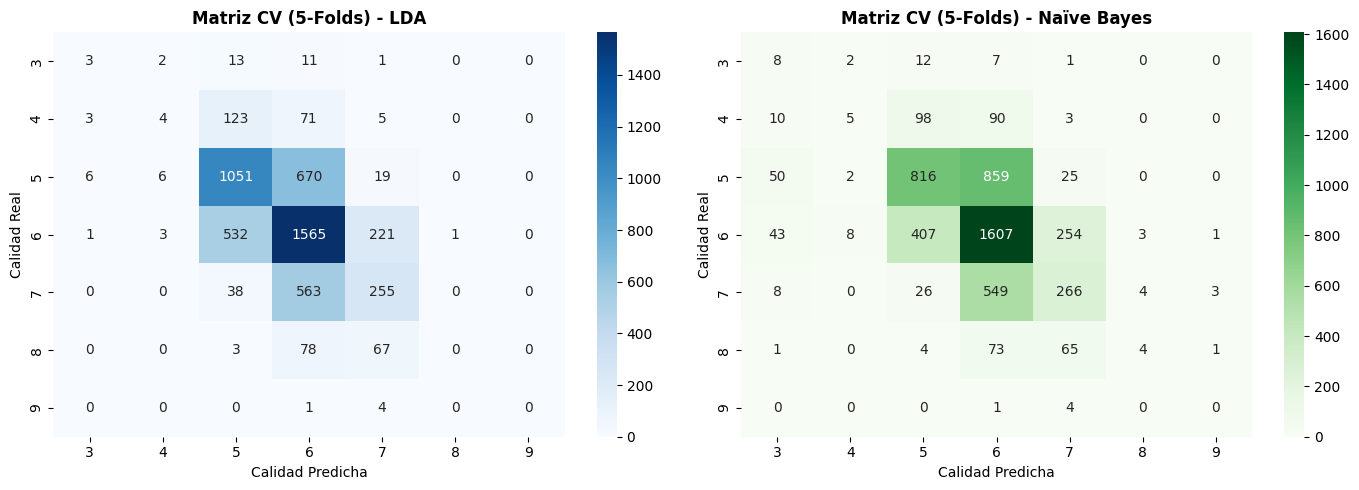

In [74]:
# 1. Definimos la estrategia: 5 cortes, barajando datos y respetando la proporción de clases
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Obtenemos las predicciones cruzadas (El modelo hace 5 exámenes y juntamos las notas)
# Usamos X_final e y_final porque el CV ya se encarga de partir los datos por dentro
pred_cv_lda = cross_val_predict(modelo_lda, X_final, y_final, cv=skf)
pred_cv_nb = cross_val_predict(modelo_nb, X_final, y_final, cv=skf)

# 3. Definimos las etiquetas reales para que no se coma ninguna fila ni columna
todas_las_calidades = [3, 4, 5, 6, 7, 8, 9]

# 4. Imprimimos los reportes completos
print("--- REPORTE CROSS-VALIDATION (5-Folds): LDA ---")
print(classification_report(y_final, pred_cv_lda, labels=todas_las_calidades, zero_division=0))

print("--- REPORTE CROSS-VALIDATION (5-Folds): NAÏVE BAYES ---")
print(classification_report(y_final, pred_cv_nb, labels=todas_las_calidades, zero_division=0))

# 5. Dibujamos las Matrices de Confusión globales del Cross-Validation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz CV LDA
sns.heatmap(confusion_matrix(y_final, pred_cv_lda, labels=todas_las_calidades), 
            annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=todas_las_calidades, yticklabels=todas_las_calidades)
axes[0].set_title('Matriz CV (5-Folds) - LDA', fontweight='bold')
axes[0].set_xlabel('Calidad Predicha')
axes[0].set_ylabel('Calidad Real')

# Matriz CV Naïve Bayes
sns.heatmap(confusion_matrix(y_final, pred_cv_nb, labels=todas_las_calidades), 
            annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=todas_las_calidades, yticklabels=todas_las_calidades)
axes[1].set_title('Matriz CV (5-Folds) - Naïve Bayes', fontweight='bold')
axes[1].set_xlabel('Calidad Predicha')
axes[1].set_ylabel('Calidad Real')

plt.tight_layout()
plt.show()

### 5.4. Análisis Cuantitativo de Resultados (Cross-Validation con PCA)

La Validación Cruzada de 5 particiones sobre la totalidad del dataset (5,320 muestras) confirma de manera definitiva que las deficiencias detectadas en el caso anterior no fueron un sesgo aleatorio, sino una limitación estructural del enfoque actual:

**1. Consolidación de la Precisión Engañosa:**
El *Accuracy* medio se estabiliza en un **54% para LDA** y un **51% para Naïve Bayes**. Al observar la matriz de confusión global del LDA, vemos que de sus 2,877 aciertos totales, más de la mitad (1,563 aciertos) provienen exclusivamente de predecir la clase 6. Esto ratifica matemáticamente el sesgo de los algoritmos hacia la clase mayoritaria.

**2. Fracaso Absoluto en Vinos de Alta Calidad:**
El dato más crítico lo revela la clase 8. Tenemos un total de **148 vinos excelentes** (support = 148). 
* El modelo **LDA** es completamente ciego a ellos: obtiene un *Recall* de **0.00**, clasificando estos 148 vinos mayoritariamente como si fueran de calidad 6 (79 veces) o calidad 7 (66 veces). 
* El modelo **Naïve Bayes** apenas logra un *Recall* de **0.03**, identificando correctamente solo 5 de esos 148 vinos, y fallando estrepitosamente en el resto.
Para la clase 9 (5 muestras en total), el fracaso es del 100% en ambos algoritmos.

**3. Intentos Erráticos en Calidades Bajas:**
En el otro extremo (calidades 3 y 4), vemos que el LDA acierta 3 vinos de calidad 3 y 4 vinos de calidad 4 en todo el dataset (Recall de 0.10 y 0.02). El Naïve Bayes se arriesga más con la clase 3 (logra un Recall de 0.27, encontrando 8 vinos), pero a cambio de hundir su *Precision* a un 0.07 debido a la cantidad de falsos positivos que genera.

**Conclusión Final de la fase PCA:**
Con un rigor estadístico validado, concluimos que la proyección espacial del PCA (incluso reteniendo el 95% de la varianza) acoplada a clasificadores probabilísticos es insuficiente. La pérdida de ese 5% de información original podría haber borrado las sutiles huellas químicas que diferencian un vino "bueno" (7) de uno "excelente" (8). 

Para comprobar si esta pérdida de resolución es culpa del desbalanceo, de los modelos, o de la propia reducción del PCA, el experimento final consistirá en **entrenar y evaluar estos mismos modelos utilizando el dataset químico original (escalado, pero sin reducción dimensional)**.

### 5.5. Evaluación de Modelos con el Dataset Original (Sin PCA)

Como último experimento para comprender las limitaciones predictivas observadas, vamos a entrenar y evaluar los modelos LDA y Naïve Bayes utilizando el conjunto de características químicas originales (previamente escaladas mediante `StandardScaler`, pero sin aplicar reducción de dimensionalidad). 

Utilizaremos el mismo método de partición inicial para poder comparar en igualdad de condiciones si la pérdida del 5% de varianza durante el PCA eliminó matices necesarios para identificar las clases minoritarias, o si el problema reside puramente en los algoritmos probabilísticos frente al desbalanceo.

--- REPORTE DETALLADO (SIN PCA): LDA ---
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.27      0.07      0.12        41
           5       0.56      0.58      0.57       350
           6       0.52      0.64      0.57       465
           7       0.45      0.27      0.34       171
           8       0.00      0.00      0.00        30
           9       0.00      0.00      0.00         1

    accuracy                           0.52      1064
   macro avg       0.26      0.22      0.23      1064
weighted avg       0.49      0.52      0.50      1064

--- REPORTE DETALLADO (SIN PCA): NAÏVE BAYES ---
              precision    recall  f1-score   support

           3       0.08      0.17      0.11         6
           4       0.18      0.12      0.14        41
           5       0.48      0.48      0.48       350
           6       0.49      0.43      0.46       465
           7       0.35      0.44      0.3

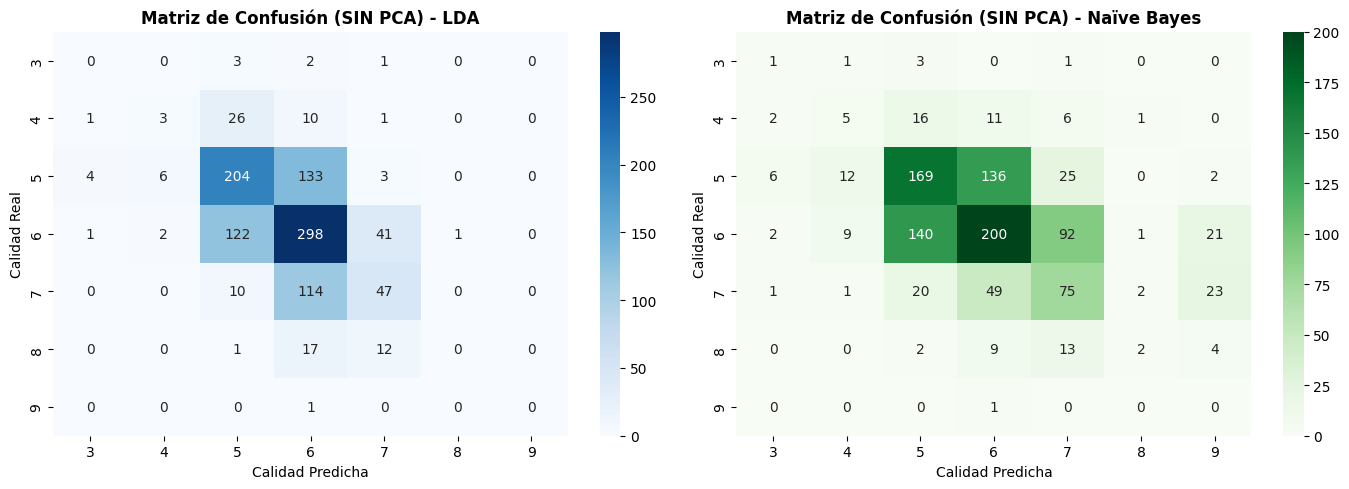

In [77]:
# 1. Recuperamos el dataset escalado original
# y lo separamos junto con la variable objetivo
X_orig = X_scaled_df 
y_orig = df['quality']

# 2. Dividimos en Entrenamiento (80%) y Prueba (20%) respetando proporciones
X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(
    X_orig, y_orig, test_size=0.2, random_state=42, stratify=y_orig
)

# 3. Instanciamos y entrenamos los modelos con todas las dimensiones originales
lda_orig = LinearDiscriminantAnalysis()
nb_orig = GaussianNB()

lda_orig.fit(X_train_orig, y_train_orig)
nb_orig.fit(X_train_orig, y_train_orig)

# 4. Realizamos las predicciones sobre el 20% de test
pred_lda_orig = lda_orig.predict(X_test_orig)
pred_nb_orig = nb_orig.predict(X_test_orig)

# 5. Definimos las etiquetas reales para los reportes y matrices
todas_las_calidades = [3, 4, 5, 6, 7, 8, 9]

# 6. Imprimimos los reportes completos
print("--- REPORTE DETALLADO (SIN PCA): LDA ---")
print(classification_report(y_test_orig, pred_lda_orig, labels=todas_las_calidades, zero_division=0))

print("--- REPORTE DETALLADO (SIN PCA): NAÏVE BAYES ---")
print(classification_report(y_test_orig, pred_nb_orig, labels=todas_las_calidades, zero_division=0))

# 7. Dibujamos las Matrices de Confusión
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz LDA (Sin PCA)
sns.heatmap(confusion_matrix(y_test_orig, pred_lda_orig, labels=todas_las_calidades), 
            annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=todas_las_calidades, yticklabels=todas_las_calidades)
axes[0].set_title('Matriz de Confusión (SIN PCA) - LDA', fontweight='bold')
axes[0].set_xlabel('Calidad Predicha')
axes[0].set_ylabel('Calidad Real')

# Matriz Naïve Bayes (Sin PCA)
sns.heatmap(confusion_matrix(y_test_orig, pred_nb_orig, labels=todas_las_calidades), 
            annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=todas_las_calidades, yticklabels=todas_las_calidades)
axes[1].set_title('Matriz de Confusión (SIN PCA) - Naïve Bayes', fontweight='bold')
axes[1].set_xlabel('Calidad Predicha')
axes[1].set_ylabel('Calidad Real')

plt.tight_layout()
plt.show()

### 5.5. Análisis Cuantitativo de Resultados (Sin PCA - Hold-Out)

Al entrenar los modelos LDA y Naïve Bayes con el dataset químico original (variables escaladas pero sin reducción de dimensionalidad), comprobamos si la pérdida del 5% de varianza provocada por el PCA fue la causa del bajo rendimiento en las clases minoritarias. Los resultados demuestran lo contrario:

**1. El LDA sigue ciego al desbalanceo:**
A pesar de tener acceso a todas las características químicas originales, el LDA mantiene su precisión global en un **52%** (idéntica a la obtenida con PCA). Lo más importante: **sigue fracasando totalmente en los extremos**. Su `recall` para las clases 3, 8 y 9 sigue siendo **0.00**. El modelo lineal no es capaz de trazar una frontera que aísle un vino excelente, sin importar si usa componentes principales o variables químicas puras.

**2. Naïve Bayes empeora con la colinealidad:**
El caso de Naïve Bayes es revelador. Su precisión global (**Accuracy**) ha caído del 49% (con PCA) al **42%** (sin PCA).
* *Explicación teórica:* Como vimos en el EDA, variables como el `alcohol` y la `density` tienen una fuerte correlación (colinealidad). El algoritmo Naïve Bayes asume que todas las variables son 100% independientes. Al quitarle el PCA (que eliminaba esta colinealidad), el modelo se "confunde" por la información redundante, lo que justifica esta bajada de rendimiento.
* A pesar de esto, vemos un tímido intento: logra un *Recall* de 0.07 en la clase 8 (acertando 2 vinos excelentes), pero a costa de clasificar peor las clases mayoritarias (5 y 6).

**Conclusión parcial:**
Este experimento demuestra que **el PCA no fue el problema**. De hecho, el PCA demostró ser muy útil: logramos el mismo nivel de precisión (52% en LDA) utilizando solo 9 columnas en lugar de las 11 originales, optimizando el cálculo. El verdadero "culpable" del fracaso en la predicción de vinos atípicos es la incapacidad de estos modelos probabilísticos lineales para gestionar el severo desbalanceo natural del dataset.

### 5.6. Validación Cruzada (Cross-Validation) SIN PCA

Para dar por concluido el experimento con el máximo rigor estadístico, someteremos los modelos a una Validación Cruzada Estratificada (5-Folds) utilizando todas las características químicas originales. 

Al igual que hicimos en el espacio PCA, utilizaremos la función `cross_val_predict` para que los algoritmos realicen predicciones sobre el 100% de la muestra (5,320 vinos) en 5 iteraciones distintas. Esto nos dará la radiografía definitiva y sin sesgos de cómo se comportan los clasificadores probabilísticos ante la colinealidad natural y el desbalanceo del dataset original.

--- REPORTE CV (5-Folds) SIN PCA: LINEAR DISCRIMINANT ANALYSIS ---
              precision    recall  f1-score   support

           3       0.18      0.10      0.13        30
           4       0.46      0.12      0.19       206
           5       0.60      0.59      0.60      1752
           6       0.53      0.67      0.59      2323
           7       0.46      0.30      0.37       856
           8       0.00      0.00      0.00       148
           9       0.00      0.00      0.00         5

    accuracy                           0.54      5320
   macro avg       0.32      0.26      0.27      5320
weighted avg       0.52      0.54      0.52      5320

--- REPORTE CV (5-Folds) SIN PCA: NAÏVE BAYES ---
              precision    recall  f1-score   support

           3       0.10      0.17      0.13        30
           4       0.15      0.11      0.13       206
           5       0.53      0.50      0.52      1752
           6       0.49      0.37      0.42      2323
           7   

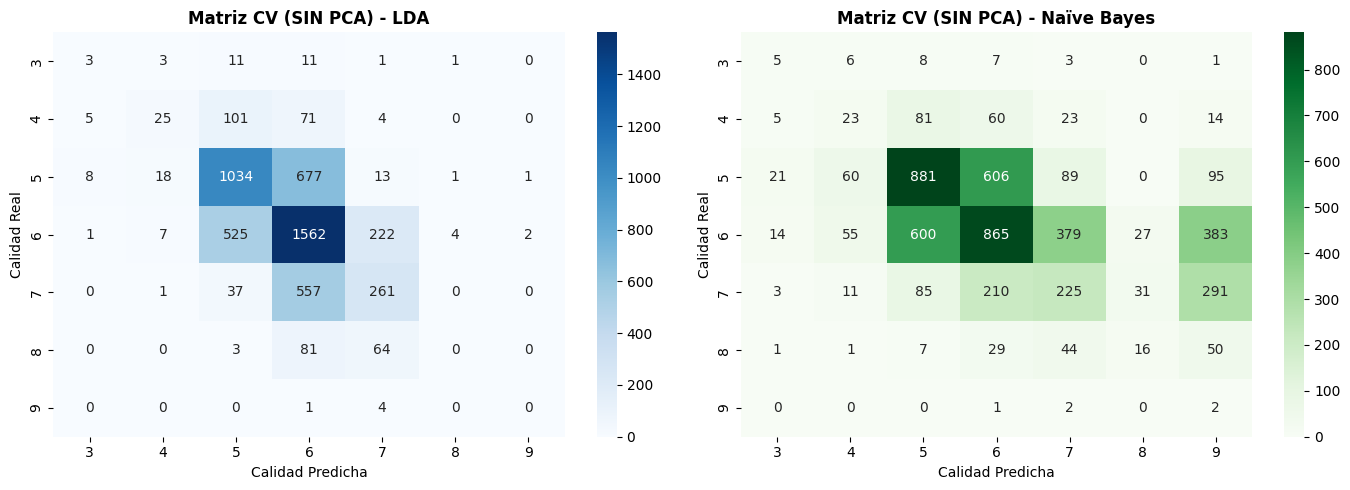

In [78]:
# 1. Recuperamos el dataset original escalado completo y la variable objetivo
X_orig = X_scaled_df 
y_orig = df['quality']

# 2. Instanciamos los modelos limpios para la validación cruzada
lda_cv_orig = LinearDiscriminantAnalysis()
nb_cv_orig = GaussianNB()

# 3. Definimos la estrategia: 5 cortes, barajando datos y respetando proporciones
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 4. Obtenemos las predicciones cruzadas sobre el dataset ORIGINAL
pred_cv_lda_orig = cross_val_predict(lda_cv_orig, X_orig, y_orig, cv=skf)
pred_cv_nb_orig = cross_val_predict(nb_cv_orig, X_orig, y_orig, cv=skf)

# 5. Definimos las etiquetas reales para los gráficos
todas_las_calidades = [3, 4, 5, 6, 7, 8, 9]

# 6. Imprimimos los reportes completos validados cruzadamente
print("--- REPORTE CV (5-Folds) SIN PCA: LINEAR DISCRIMINANT ANALYSIS ---")
print(classification_report(y_orig, pred_cv_lda_orig, labels=todas_las_calidades, zero_division=0))

print("--- REPORTE CV (5-Folds) SIN PCA: NAÏVE BAYES ---")
print(classification_report(y_orig, pred_cv_nb_orig, labels=todas_las_calidades, zero_division=0))

# 7. Dibujamos las Matrices de Confusión Globales
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz CV LDA (Sin PCA)
sns.heatmap(confusion_matrix(y_orig, pred_cv_lda_orig, labels=todas_las_calidades), 
            annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=todas_las_calidades, yticklabels=todas_las_calidades)
axes[0].set_title('Matriz CV (SIN PCA) - LDA', fontweight='bold')
axes[0].set_xlabel('Calidad Predicha')
axes[0].set_ylabel('Calidad Real')

# Matriz CV Naïve Bayes (Sin PCA)
sns.heatmap(confusion_matrix(y_orig, pred_cv_nb_orig, labels=todas_las_calidades), 
            annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=todas_las_calidades, yticklabels=todas_las_calidades)
axes[1].set_title('Matriz CV (SIN PCA) - Naïve Bayes', fontweight='bold')
axes[1].set_xlabel('Calidad Predicha')
axes[1].set_ylabel('Calidad Real')

plt.tight_layout()
plt.show()

### 5.6. Conclusión General del Proyecto: PCA y Modelado Probabilístico

Tras someter a los algoritmos LDA y Naïve Bayes a una Validación Cruzada de 5 particiones utilizando tanto el espacio dimensional reducido (PCA) como el conjunto de características originales, extraemos las conclusiones definitivas del estudio:

**1. Éxito de la Reducción de Dimensionalidad (PCA):**
El rendimiento del modelo LDA se ha mantenido idéntico (54% de Accuracy) en ambos escenarios, fracasando igualmente en la detección de clases minoritarias. Esto demuestra empíricamente que la compresión del PCA fue un éxito: logramos la misma capacidad predictiva utilizando un número menor de variables, optimizando el coste computacional y confirmando que la pérdida de ese 5% de varianza no contenía la "clave" para diferenciar los vinos extremos.

**2. El impacto de la Colinealidad en Naïve Bayes:**
La validación cruzada ha demostrado el inmenso beneficio del PCA sobre el modelo Naïve Bayes. Al utilizar los datos originales, su *Accuracy* se desploma del 51% al **38%**. Este colapso se explica por la fuerte colinealidad presente en las variables químicas originales (como `alcohol` y `density`), la cual viola la asunción de independencia del Teorema de Bayes. El PCA resolvió este problema de forma nativa al transformar el dataset en componentes principales ortogonales (matemáticamente independientes).

**3. Diagnóstico del Problema Central (El Desbalanceo):**
El fracaso de ambos algoritmos para identificar vinos de calidades extremas (3, 4, 8 y 9) no es un problema de las características químicas, sino de la naturaleza de los clasificadores probabilísticos lineales aplicados a un conjunto de datos severamente desbalanceado. Ante la abrumadora mayoría de muestras de calidad 5 y 6, las fronteras de decisión de estos modelos colapsan hacia la clase mayoritaria por pura probabilidad estadística.